In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import imageio  # for GIF creation
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== LOAD YOUR MODEL =====
# Option A: from Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# MODEL_PATH = "/content/drive/MyDrive/soc_diffusion/week5/face_vae_final.pt"

# Option B: upload directly
# from google.colab import files
# uploaded = files.upload()
# MODEL_PATH = list(uploaded.keys())[0]

MODEL_PATH = "really the best so far.pt"  # [PLAY] change to your file path

# Recreate the model architecture (must match Week 5 exactly)
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        # Encoder
        self.encoder_net = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),  # 64 -> 32
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 32 -> 16
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2 , padding =1), # 16 -> 8
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256,512, kernel_size=3, stride=2, padding= 1), # 8->4
            nn.BatchNorm2d(512),
            nn.ReLU(),
            
            nn.Flatten() # 512 * 4 * 4= 8192
        )

        self.mu = nn.Linear(8192, latent_dim)
        self.logvar = nn.Linear(8192, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 8192)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1), 
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_net(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.reshape(-1, 512, 4, 4).contiguous() # reshape to (-1 , last_channel, spatialsize=64/2^4,spatialsize)
        return self.deconv(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)

        return x_hat, mu, logvar

model = VAE(latent_dim=128).to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device)

new_state_dict = {
    k.replace("_orig_mod.", ""): v
    for k, v in checkpoint.items()
}

model.load_state_dict(new_state_dict)
model.eval()
print("Model loaded successfully!")

# Load CelebA for exploration
image_size = 64
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
])

# Load with attributes for Part 3 (attribute discovery)
dataset_with_attrs = datasets.CelebA(
    root="./data", split="train", download=False,
    transform=transform, target_type='attr'
)

# Also a plain version for encoder-only use
dataset = datasets.CelebA(
    root="./data", split="train", download=False,
    transform=transform
)

loader = DataLoader(dataset, batch_size=2048, shuffle=True)

Model loaded successfully!


GIF saved as face_morph.gif


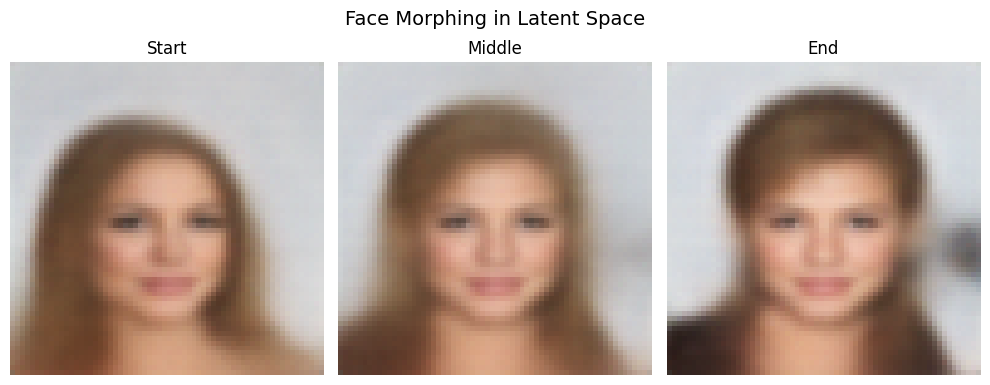

In [2]:
@torch.no_grad()
def face_morph(model, img1, img2, steps=30):  # [PLAY] more steps = smoother GIF
    """
    img1, img2: [1, 3, 64, 64] tensors
    Returns: list of [3, 64, 64] numpy arrays (the morph frames)
    """
    # Encode both faces
    mu1, _ = model.encode(img1.to(device))
    mu2, _ = model.encode(img2.to(device))

    frames = []
    for alpha in np.linspace(0, 1, steps):
        # Spherical interpolation (slerp) gives smoother morphs than linear
        # But linear works fine for small steps. Use linear for simplicity:
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        recon = model.decode(z_interp)
        frame = recon[0].cpu().permute(1, 2, 0).numpy()
        frame = np.clip(frame, 0, 1)
        frames.append((frame * 255).astype(np.uint8))

    return frames


# Get two random faces
x, _ = next(iter(loader))
img1 = x[0:1]
img2 = x[1:2]

# Generate morph
frames = face_morph(model, img1, img2, steps=30)

# Save as GIF
imageio.mimsave('face_morph.gif', frames, duration=0.1, loop=0)
print("GIF saved as face_morph.gif")

# Show start, middle, end
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(frames[0])
axes[0].set_title("Start", fontsize=12)
axes[0].axis('off')
axes[1].imshow(frames[15])
axes[1].set_title("Middle", fontsize=12)
axes[1].axis('off')
axes[2].imshow(frames[-1])
axes[2].set_title("End", fontsize=12)
axes[2].axis('off')
plt.suptitle("Face Morphing in Latent Space", fontsize=14)
plt.tight_layout()
plt.show()

Computing 'Smiling' vector...


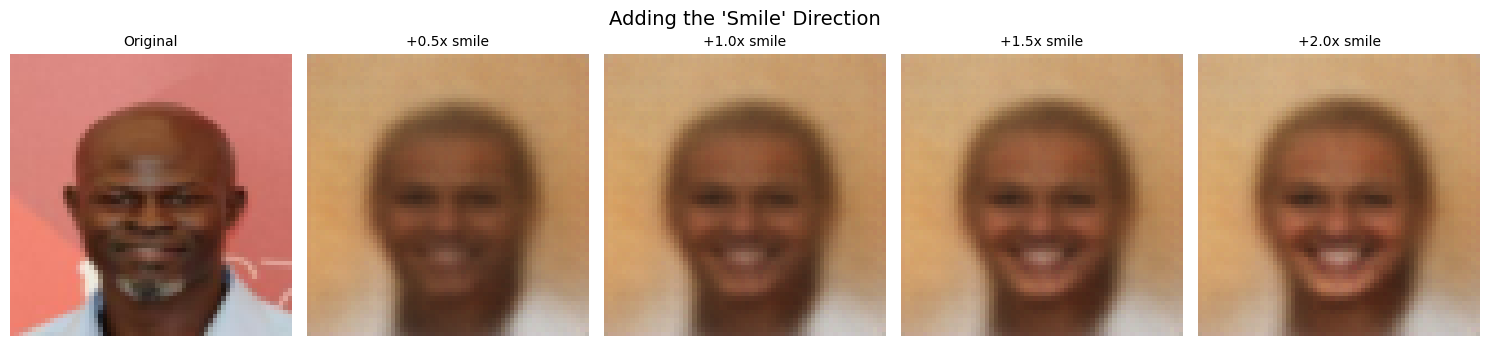

In [20]:
@torch.no_grad()
def encode_batch(model, loader, max_batch=1000):
    """Encode a batch of images to get their mu vectors."""
    all_mu = []
    all_attrs = None
    for x, attrs in loader:
        mu, _ = model.encode(x.to(device))
        all_mu.append(mu.cpu())
        if all_attrs is None:
            all_attrs = attrs
        else:
            all_attrs = torch.cat([all_attrs, attrs])
        if len(torch.cat(all_mu)) >= max_batch:
            break
    return torch.cat(all_mu), all_attrs


# CelebA attributes: each row is a 40-dim binary vector
# Index mapping (see https://github.com/taki0112/CelebA/blob/master/list_attr_celeba.txt)
ATTR_NAMES = [
    '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes',
    'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair',
    'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin',
    'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones',
    'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard',
    'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline',
    'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair',
    'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick',
    'Wearing_Necklace', 'Wearing_Necktie', 'Young'
]

def get_attribute_vector(model, loader_with_attrs, attr_name, n_samples=2000):  # [PLAY] more samples = cleaner vector
    """
    Find the latent direction for an attribute.
    Returns: vector of shape [latent_dim]
    """
    attr_idx = ATTR_NAMES.index(attr_name)

    # Encode faces
    mu_vectors, attr_labels = encode_batch(model, loader_with_attrs, max_batch=n_samples)

    # Split into with and without the attribute
    has_attr = attr_labels[:, attr_idx] == 1
    no_attr  = attr_labels[:, attr_idx] == 0  # CelebA uses -1 for False

    mu_with = mu_vectors[has_attr]
    mu_without = mu_vectors[no_attr]

    if len(mu_with) < 10 or len(mu_without) < 10:
        print(f"Warning: not enough samples for '{attr_name}'. Got {len(mu_with)}/{len(mu_without)}")
        return None

    # Attribute vector = average(with_attr) - average(without_attr)
    attr_vector = mu_with.mean(dim=0) - mu_without.mean(dim=0)
    return attr_vector


@torch.no_grad()
def apply_attribute(model, img, attr_vector, strength=1.0):  # [PLAY] try 0.5, 2.0, 3.0
    """Add an attribute vector to a face's latent code."""
    mu, _ = model.encode(img.to(device))
    mu_modified = mu + strength * attr_vector.to(device)
    recon = model.decode(mu_modified)
    return recon.cpu()


# Load attribute-labeled data
attr_loader = DataLoader(dataset_with_attrs, batch_size=2048, shuffle=True)

# Find the "Smiling" direction
print("Computing 'Smiling' vector...")
smile_vector = get_attribute_vector(model, attr_loader, 'Smiling', n_samples=5000)

if smile_vector is not None:
    # Apply to a neutral face
    x, _ = next(iter(loader))
    test_face = x[0:1]

    fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
    axes[0].imshow(test_face[0].permute(1, 2, 0))
    axes[0].set_title("Original", fontsize=10)
    axes[0].axis('off')

    for i, strength in enumerate([0.5, 1.0, 1.5, 2.0]):
        modified = apply_attribute(model, test_face, smile_vector, strength=strength)
        axes[i+1].imshow(modified[0].permute(1, 2, 0))
        axes[i+1].set_title(f"+{strength}x smile", fontsize=10)
        axes[i+1].axis('off')

    plt.suptitle("Adding the 'Smile' Direction", fontsize=14)
    plt.tight_layout()
    plt.show()

Computing attribute vectors...


 20%|█████████▍                                     | 1/5 [00:01<00:05,  1.42s/it]

  Smiling: vector norm = 1.367


 40%|██████████████████▊                            | 2/5 [00:02<00:04,  1.33s/it]

  Male: vector norm = 1.354


...

  Eyeglasses: vector norm = 1.766


 80%|█████████████████████████████████████▌         | 4/5 [00:05<00:01,  1.28s/it]

  Young: vector norm = 1.015


100%|███████████████████████████████████████████████| 5/5 [00:06<00:00,  1.28s/it]

  Pale_Skin: vector norm = 2.035

Found 5/5 attribute directions


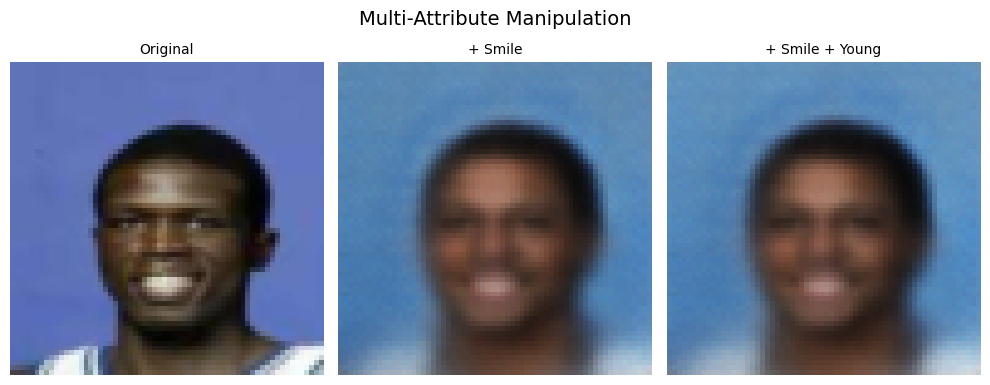

In [11]:
# Find multiple attribute directions
attributes_to_find = ['Smiling', 'Male', 'Eyeglasses', 'Young', 'Pale_Skin']
attr_vectors = {}

print("Computing attribute vectors...")
for attr in tqdm(attributes_to_find):
    vec = get_attribute_vector(model, attr_loader, attr, n_samples=2000)
    if vec is not None:
        attr_vectors[attr] = vec
        print(f"  {attr}: vector norm = {vec.norm():.3f}")

print(f"\nFound {len(attr_vectors)}/{len(attributes_to_find)} attribute directions")

# Cross-attribute arithmetic: make a non-smiling man smile
if 'Smiling' in attr_vectors and 'Male' in attr_vectors:
    test_face = x[5:6]  # another random face

    mu, _ = model.encode(test_face.to(device))

    # Apply smiling
    mu_smiling = mu + attr_vectors['Smiling'].to(device)

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    axes[0].imshow(test_face[0].permute(1, 2, 0))
    axes[0].set_title("Original", fontsize=10)
    axes[0].axis('off')

    recon_smile = model.decode(mu_smiling)
    axes[1].imshow(recon_smile[0].detach().cpu().permute(1, 2, 0))
    axes[1].set_title("+ Smile", fontsize=10)
    axes[1].axis('off')

    # Apply multiple attributes
    mu_combo = mu + attr_vectors['Smiling'].to(device) + attr_vectors['Young'].to(device) * 0.5
    recon_combo = model.decode(mu_combo)
    axes[2].imshow(recon_combo[0].detach().cpu().permute(1, 2, 0))
    axes[2].set_title("+ Smile + Young", fontsize=10)
    axes[2].axis('off')

    plt.suptitle("Multi-Attribute Manipulation", fontsize=14)
    plt.tight_layout()
    plt.show()

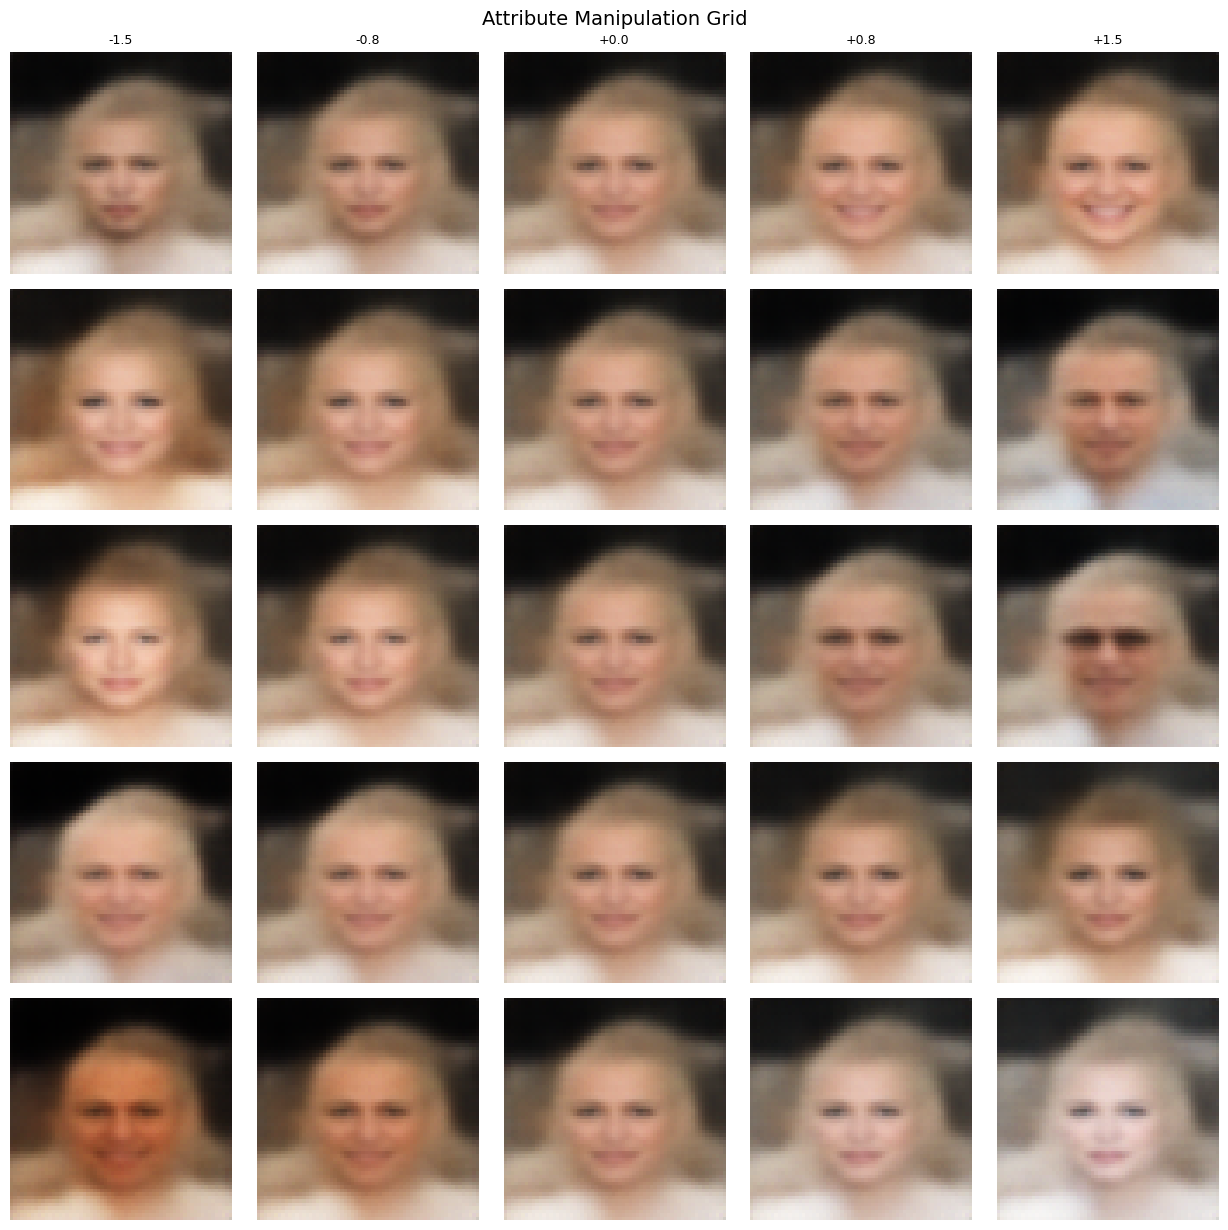

In [15]:
@torch.no_grad()
def attribute_grid(model, loader, attr_vectors, face_idx=0, strengths=[-1.5, -0.75, 0, 0.75, 1.5] ): # [PLAY] try different strength ranges):
    """Create a grid showing one face modified by multiple attributes at multiple strengths."""
    x, _ = next(iter(loader))
    base_face = x[face_idx:face_idx+1]

    n_attrs = len(attr_vectors)
    n_strengths = len(strengths)

    fig, axes = plt.subplots(n_attrs, n_strengths,
                             figsize=(n_strengths * 2.5, n_attrs * 2.5))

    for row, (attr_name, vec) in enumerate(attr_vectors.items()):
        for col, strength in enumerate(strengths):
            modified = apply_attribute(model, base_face, vec, strength=strength)
            axes[row, col].imshow(modified[0].permute(1, 2, 0))
            axes[row, col].axis('off')

            if col == 0:
                axes[row, col].set_ylabel(attr_name, fontsize=10, rotation=0,
                                         labelpad=50, va='center')
            if row == 0:
                axes[row, col].set_title(f"{strength:+.1f}", fontsize=9)

    plt.suptitle("Attribute Manipulation Grid", fontsize=14)
    plt.tight_layout()
    plt.show()

if len(attr_vectors) >= 3:
    attribute_grid(model, loader, attr_vectors)

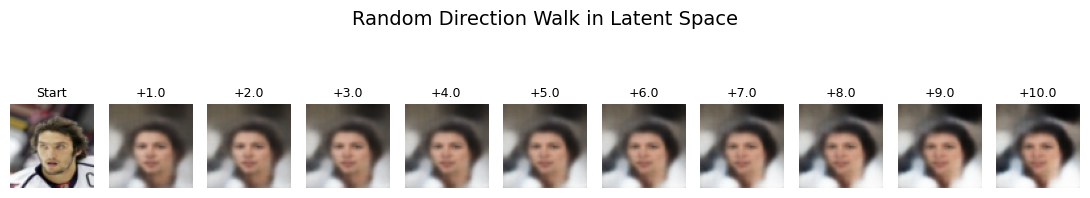

In [19]:
@torch.no_grad()
def random_walk(model, base_face, n_steps=10, step_size=0.5):  # [PLAY] try n_steps=20, step_size=2.0
    """Walk in a random direction from a face's latent code."""
    mu, _ = model.encode(base_face.to(device))

    # Pick a random unit direction
    random_direction = torch.randn(1, 128).to(device)
    random_direction = random_direction / random_direction.norm()

    fig, axes = plt.subplots(1, n_steps + 1, figsize=(n_steps + 1, 2.5))
    axes[0].imshow(base_face[0].permute(1, 2, 0))
    axes[0].set_title("Start", fontsize=9)
    axes[0].axis('off')

    for i in range(1, n_steps + 1):
        z = mu + step_size * i * random_direction
        recon = model.decode(z)
        axes[i].imshow(recon[0].cpu().permute(1, 2, 0))
        axes[i].set_title(f"+{i*step_size:.1f}", fontsize=9)
        axes[i].axis('off')

    plt.suptitle("Random Direction Walk in Latent Space", fontsize=14)
    plt.tight_layout()
    plt.show()

x, _ = next(iter(loader))
random_walk(model, x[3:4], n_steps=10, step_size=1.0)  # [PLAY] explore different directions